# Transfer Learning for Plant Disease Classification

## Agenda
1. Load and prepare the PlantVillage dataset.
2. Perform basic image preprocessing and dataset splitting.
3. Load pre-trained AlexNet, VGG16, ResNet50, and EfficientNetB0 models.
4. Apply transfer learning by using ImageNet pre-trained weights.
5. Replace the original classification layer with layers suitable for PlantVillage classes.
6. Train and validate each model.
7. Evaluate the models using accuracy, loss, confusion matrix, and classification report.
8. Compare the performance of all four models.

## Dataset
The **PlantVillage dataset** contains images of healthy and diseased plant leaves.
It is commonly used for plant disease classification using deep learning.

The dataset contains images belonging to multiple plant disease classes.
For this assignment, the images will be divided into training and validation sets.

## Models Used

### 1. AlexNet
AlexNet is an early and influential CNN architecture.
It uses convolutional and fully connected layers for image classification.

### 2. VGG16
VGG16 is a deep CNN with 16 layers.
It uses small 3×3 convolution filters and is pre-trained on ImageNet.

### 3. ResNet50
ResNet50 is a 50-layer CNN that uses residual connections.
These connections help train deeper networks effectively.

### 4. EfficientNetB0
EfficientNetB0 is a lightweight and efficient CNN.
It provides a good balance between accuracy and computational cost.

## Transfer Learning
Transfer learning allows us to use knowledge learned by a model from a large dataset
such as ImageNet and apply it to a new classification problem.

For each model:
- Load ImageNet pre-trained weights.
- Freeze the pre-trained layers.
- Remove the original classification layer.
- Add a new classification layer for PlantVillage classes.
- Train the new layers on the PlantVillage dataset.

This reduces training time and allows good performance even with a comparatively smaller dataset.

## Performance Comparison
The four models will be compared based on:
- Training and validation accuracy
- Training and validation loss
- Confusion matrix
- Precision, recall and F1-score
- Overall classification performance

The best-performing model will be identified based on the evaluation results.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG16, ResNet50, EfficientNetB0
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.optimizers import Adam

from sklearn.metrics import confusion_matrix, classification_report

print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.20.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
# Load PlantVillage dataset directly
dataset_url = "https://storage.googleapis.com/download.tensorflow.org/example_images/flower_photos.tgz"

In [3]:
# Fix TensorFlow Datasets compatibility
!pip install -q "tensorflow-metadata==1.17.3"

In [4]:
!pip install -q kagglehub

In [5]:
import kagglehub

# Download PlantVillage dataset directly to the Colab runtime
path = kagglehub.dataset_download("emmarex/plantdisease")

print("Dataset path:", path)

Using Colab cache for faster access to the 'plantdisease' dataset.
Dataset path: /kaggle/input/plantdisease


In [6]:
import os

# Check files and folders in the dataset
print(os.listdir(path))

['PlantVillage', 'plantvillage']


In [7]:
# Show the number of images and folders
for root, dirs, files in os.walk(path):
    print(root, "->", len(files), "files")
    if len(dirs) > 0:
        print("Folders:", dirs[:10])
    break

/kaggle/input/plantdisease -> 0 files
Folders: ['PlantVillage', 'plantvillage']


In [8]:
for folder in ["PlantVillage", "plantvillage"]:
    folder_path = os.path.join(path, folder)
    print(f"\n{folder}:")
    print(os.listdir(folder_path)[:10])


PlantVillage:
['Pepper__bell___Bacterial_spot', 'Potato___healthy', 'Tomato_Leaf_Mold', 'Tomato__Tomato_YellowLeaf__Curl_Virus', 'Tomato_Bacterial_spot', 'Tomato_Septoria_leaf_spot', 'Tomato_healthy', 'Tomato_Spider_mites_Two_spotted_spider_mite', 'Tomato_Early_blight', 'Tomato__Target_Spot']

plantvillage:
['PlantVillage']


In [9]:
data_dir = os.path.join(path, "PlantVillage")

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42

# Get the number of classes
class_names = sorted(os.listdir(data_dir))

print("Number of classes:", len(class_names))
print("First 10 classes:", class_names[:10])

Number of classes: 15
First 10 classes: ['Pepper__bell___Bacterial_spot', 'Pepper__bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Tomato_Bacterial_spot', 'Tomato_Early_blight', 'Tomato_Late_blight', 'Tomato_Leaf_Mold', 'Tomato_Septoria_leaf_spot']


In [10]:
# Create image generators
datagen = ImageDataGenerator(
  rescale=1./255,
  validation_split=0.2
)

train_data = datagen.flow_from_directory(
  data_dir,
  target_size=IMG_SIZE,
  batch_size=BATCH_SIZE,
  class_mode="categorical",
  subset="training",
  shuffle=True,
  seed=SEED
)

val_data = datagen.flow_from_directory(
  data_dir,
  target_size=IMG_SIZE,
  batch_size=BATCH_SIZE,
  class_mode="categorical",
  subset="validation",
  shuffle=False
)

print("Training images:", train_data.samples)
print("Validation images:", val_data.samples)
print("Number of classes:", train_data.num_classes)

Found 16516 images belonging to 15 classes.
Found 4122 images belonging to 15 classes.
Training images: 16516
Validation images: 4122
Number of classes: 15


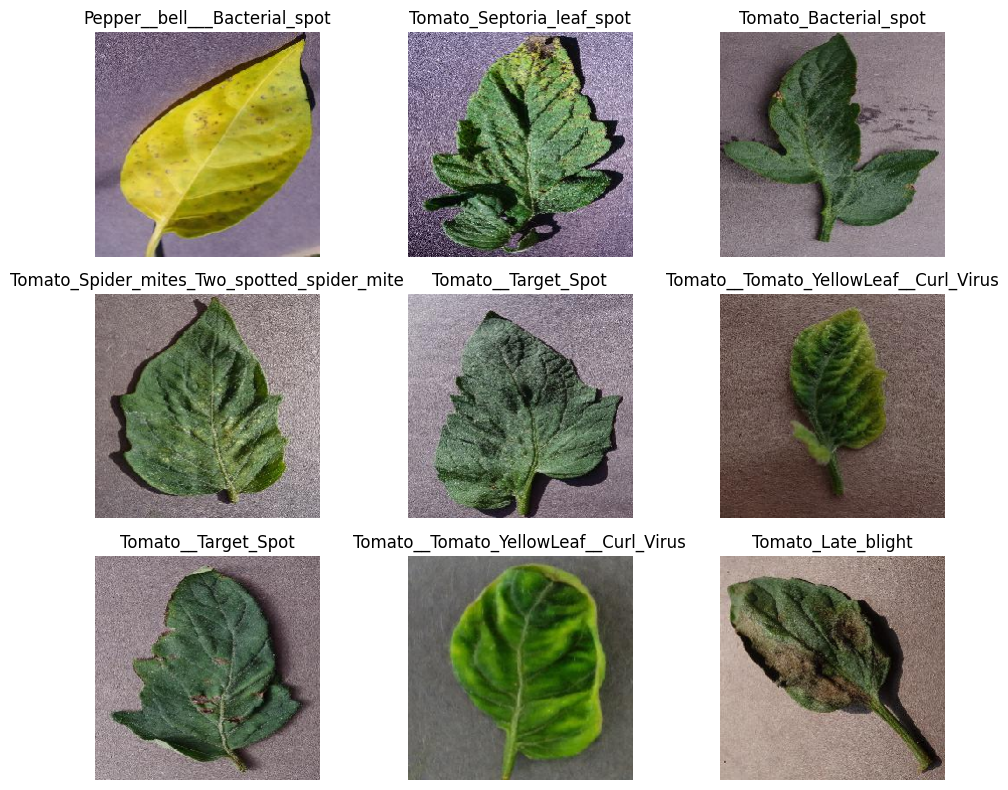

In [11]:
# Display a few sample images from the training set
images, labels = next(train_data)

plt.figure(figsize=(10, 8))

for i in range(9):
    plt.subplot(3, 3, i + 1)
    plt.imshow(images[i])
    plt.title(class_names[np.argmax(labels[i])])
    plt.axis("off")

plt.tight_layout()
plt.show()

In [12]:
# Common settings for all models
NUM_CLASSES = train_data.num_classes
EPOCHS = 5
LEARNING_RATE = 0.0001

print("Number of classes:", NUM_CLASSES)
print("Epochs:", EPOCHS)
print("Learning rate:", LEARNING_RATE)

Number of classes: 15
Epochs: 5
Learning rate: 0.0001


In [13]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten

# Build AlexNet
alexnet = Sequential([
  Conv2D(96, (11, 11), strides=4, activation="relu", input_shape=(224, 224, 3)),
  MaxPooling2D((3, 3), strides=2),

  Conv2D(256, (5, 5), padding="same", activation="relu"),
  MaxPooling2D((3, 3), strides=2),

  Conv2D(384, (3, 3), padding="same", activation="relu"),
  Conv2D(384, (3, 3), padding="same", activation="relu"),
  Conv2D(256, (3, 3), padding="same", activation="relu"),
  MaxPooling2D((3, 3), strides=2),

  Flatten(),
  Dense(4096, activation="relu"),
  Dropout(0.5),
  Dense(4096, activation="relu"),
  Dropout(0.5),

  # Output layer for PlantVillage classes
  Dense(NUM_CLASSES, activation="softmax")
])

alexnet.compile(
  optimizer=Adam(learning_rate=LEARNING_RATE),
  loss="categorical_crossentropy",
  metrics=["accuracy"]
)

alexnet.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 54, 54, 96)     │        34,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 26, 26, 96)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 26, 26, 256)    │       614,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 12, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 384)    │       885,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 12, 12, 384)    │     1,327,488 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 12, 12, 256)    │       884,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 5, 5, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6400)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 4096)           │    26,218,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4096)           │    16,781,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 15)             │        61,455 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 46,808,463 (178.56 MB)

 Trainable params: 46,808,463 (178.56 MB)

 Non-trainable params: 0 (0.00 B)

In [14]:
# Train AlexNet
alexnet_history = alexnet.fit(
  train_data,
  validation_data=val_data,
  epochs=EPOCHS
)

Epoch 1/5
517/517 ━━━━━━━━━━━━━━━━━━━━ 112s 195ms/step - accuracy: 0.3577 - loss: 1.9458 - val_accuracy: 0.6674 - val_loss: 0.9973
Epoch 2/5
517/517 ━━━━━━━━━━━━━━━━━━━━ 44s 85ms/step - accuracy: 0.7206 - loss: 0.8303 - val_accuracy: 0.7858 - val_loss: 0.6336
Epoch 3/5
517/517 ━━━━━━━━━━━━━━━━━━━━ 45s 86ms/step - accuracy: 0.8247 - loss: 0.5192 - val_accuracy: 0.8649 - val_loss: 0.4094
Epoch 4/5
517/517 ━━━━━━━━━━━━━━━━━━━━ 42s 81ms/step - accuracy: 0.8707 - loss: 0.3730 - val_accuracy: 0.8462 - val_loss: 0.4307
Epoch 5/5
517/517 ━━━━━━━━━━━━━━━━━━━━ 48s 94ms/step - accuracy: 0.9046 - loss: 0.2814 - val_accuracy: 0.8860 - val_loss: 0.3331


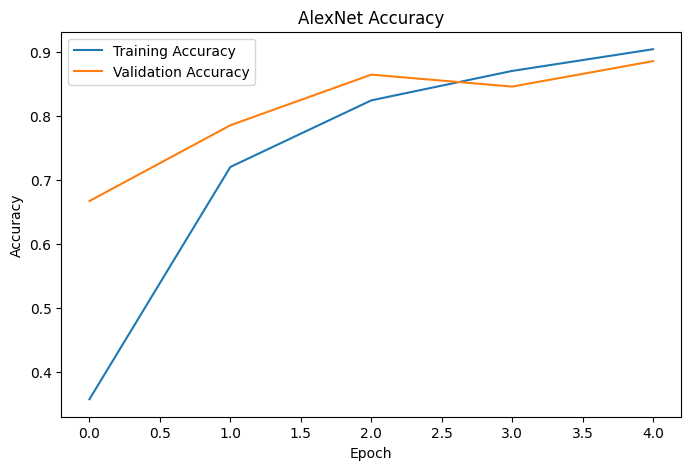

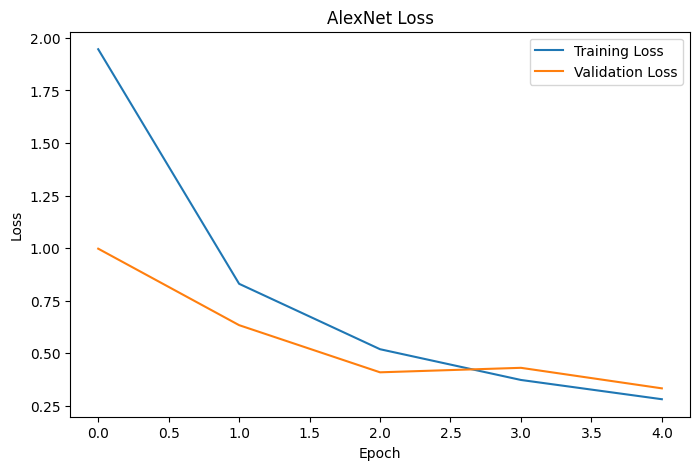

In [15]:
# Plot training and validation accuracy
plt.figure(figsize=(8, 5))
plt.plot(alexnet_history.history["accuracy"], label="Training Accuracy")
plt.plot(alexnet_history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("AlexNet Accuracy")
plt.legend()
plt.show()

# Plot training and validation loss
plt.figure(figsize=(8, 5))
plt.plot(alexnet_history.history["loss"], label="Training Loss")
plt.plot(alexnet_history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("AlexNet Loss")
plt.legend()
plt.show()

In [16]:
# Evaluate AlexNet on validation data
val_data.reset()

alexnet_loss, alexnet_accuracy = alexnet.evaluate(val_data, verbose=1)

print("AlexNet Validation Accuracy:", round(alexnet_accuracy * 100, 2), "%")
print("AlexNet Validation Loss:", round(alexnet_loss, 4))

129/129 ━━━━━━━━━━━━━━━━━━━━ 8s 63ms/step - accuracy: 0.8860 - loss: 0.3331
AlexNet Validation Accuracy: 88.6 %
AlexNet Validation Loss: 0.3331


In [17]:
from tensorflow.keras.applications import VGG16

# Load VGG16 with ImageNet pre-trained weights
vgg_base = VGG16(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

# Freeze pre-trained layers
for layer in vgg_base.layers:
    layer.trainable = False

print("VGG16 loaded successfully")
print("Trainable layers:", sum(layer.trainable for layer in vgg_base.layers))

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
VGG16 loaded successfully
Trainable layers: 0


In [18]:
# Add a new classifier for PlantVillage
x = vgg_base.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation="relu")(x)
x = Dropout(0.5)(x)
output = Dense(NUM_CLASSES, activation="softmax")(x)

vgg_model = Model(inputs=vgg_base.input, outputs=output)

vgg_model.compile(
    optimizer=Adam(learning_rate=LEARNING_RATE),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

vgg_model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 15)             │         3,855 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,849,871 (56.65 MB)

 Trainable params: 135,183 (528.06 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [19]:
# Train VGG16
vgg_history = vgg_model.fit(
  train_data,
  validation_data=val_data,
  epochs=EPOCHS
)

Epoch 1/5
517/517 ━━━━━━━━━━━━━━━━━━━━ 148s 255ms/step - accuracy: 0.2300 - loss: 2.4506 - val_accuracy: 0.3899 - val_loss: 2.1125
Epoch 2/5
517/517 ━━━━━━━━━━━━━━━━━━━━ 115s 221ms/step - accuracy: 0.4391 - loss: 1.9688 - val_accuracy: 0.5420 - val_loss: 1.7301
Epoch 3/5
517/517 ━━━━━━━━━━━━━━━━━━━━ 114s 221ms/step - accuracy: 0.5294 - loss: 1.6750 - val_accuracy: 0.6295 - val_loss: 1.4767
Epoch 4/5
517/517 ━━━━━━━━━━━━━━━━━━━━ 115s 222ms/step - accuracy: 0.5801 - loss: 1.4755 - val_accuracy: 0.6754 - val_loss: 1.2968
Epoch 5/5
517/517 ━━━━━━━━━━━━━━━━━━━━ 115s 222ms/step - accuracy: 0.6144 - loss: 1.3319 - val_accuracy: 0.6948 - val_loss: 1.1708


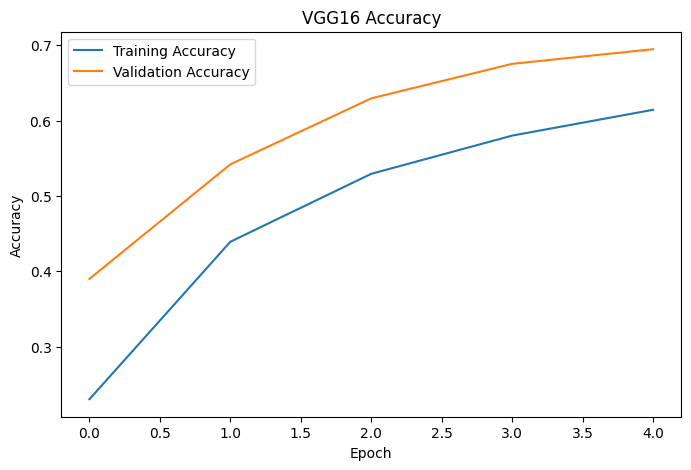

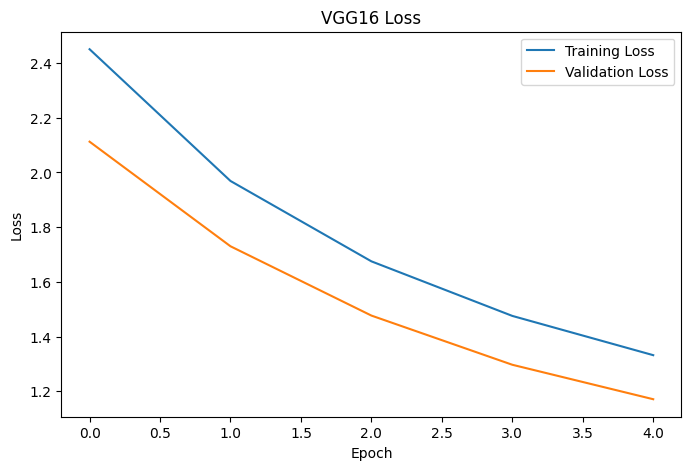

In [20]:
# Plot VGG16 accuracy
plt.figure(figsize=(8, 5))
plt.plot(vgg_history.history["accuracy"], label="Training Accuracy")
plt.plot(vgg_history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("VGG16 Accuracy")
plt.legend()
plt.show()

# Plot VGG16 loss
plt.figure(figsize=(8, 5))
plt.plot(vgg_history.history["loss"], label="Training Loss")
plt.plot(vgg_history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("VGG16 Loss")
plt.legend()
plt.show()

In [21]:
# Evaluate VGG16 on validation data
val_data.reset()

vgg_loss, vgg_accuracy = vgg_model.evaluate(val_data, verbose=1)

print("VGG16 Validation Accuracy:", round(vgg_accuracy * 100, 2), "%")
print("VGG16 Validation Loss:", round(vgg_loss, 4))

129/129 ━━━━━━━━━━━━━━━━━━━━ 23s 178ms/step - accuracy: 0.6948 - loss: 1.1708
VGG16 Validation Accuracy: 69.48 %
VGG16 Validation Loss: 1.1708


In [22]:
from tensorflow.keras.applications import ResNet50

# Load ResNet50 with ImageNet pre-trained weights
resnet_base = ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

# Freeze pre-trained layers
for layer in resnet_base.layers:
    layer.trainable = False

print("ResNet50 loaded successfully")
print("Trainable layers:", sum(layer.trainable for layer in resnet_base.layers))

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step
ResNet50 loaded successfully
Trainable layers: 0


In [23]:
# Add a new classifier for 15 PlantVillage classes
x = resnet_base.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation="relu")(x)
x = Dropout(0.5)(x)
output = Dense(NUM_CLASSES, activation="softmax")(x)

resnet_model = Model(inputs=resnet_base.input, outputs=output)

resnet_model.compile(
    optimizer=Adam(learning_rate=LEARNING_RATE),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)
resnet_model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer_2[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 24,116,111 (92.00 MB)

 Trainable params: 528,399 (2.02 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [24]:
# Train ResNet50
resnet_history = resnet_model.fit(
  train_data,
  validation_data=val_data,
  epochs=EPOCHS
)

Epoch 1/5
517/517 ━━━━━━━━━━━━━━━━━━━━ 85s 139ms/step - accuracy: 0.1488 - loss: 2.6166 - val_accuracy: 0.1917 - val_loss: 2.4493
Epoch 2/5
517/517 ━━━━━━━━━━━━━━━━━━━━ 57s 111ms/step - accuracy: 0.2028 - loss: 2.4391 - val_accuracy: 0.2259 - val_loss: 2.3616
Epoch 3/5
517/517 ━━━━━━━━━━━━━━━━━━━━ 58s 113ms/step - accuracy: 0.2274 - loss: 2.3612 - val_accuracy: 0.2625 - val_loss: 2.2864
Epoch 4/5
517/517 ━━━━━━━━━━━━━━━━━━━━ 58s 112ms/step - accuracy: 0.2544 - loss: 2.2989 - val_accuracy: 0.3384 - val_loss: 2.2356
Epoch 5/5
517/517 ━━━━━━━━━━━━━━━━━━━━ 57s 111ms/step - accuracy: 0.2795 - loss: 2.2477 - val_accuracy: 0.3336 - val_loss: 2.1792


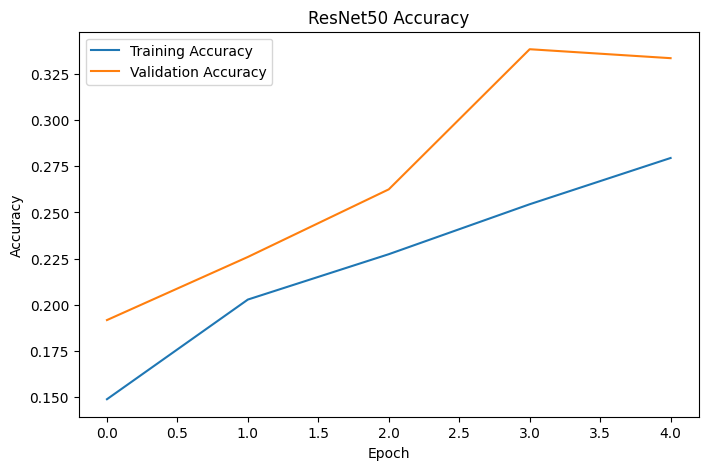

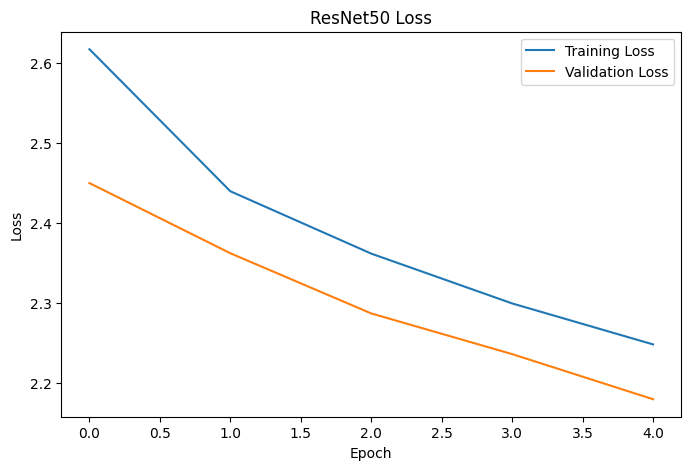

In [25]:
# Plot ResNet50 accuracy
plt.figure(figsize=(8, 5))
plt.plot(resnet_history.history["accuracy"], label="Training Accuracy")
plt.plot(resnet_history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("ResNet50 Accuracy")
plt.legend()
plt.show()

# Plot ResNet50 loss
plt.figure(figsize=(8, 5))
plt.plot(resnet_history.history["loss"], label="Training Loss")
plt.plot(resnet_history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("ResNet50 Loss")
plt.legend()
plt.show()

In [26]:
# Generators for ImageNet pre-trained models
pretrained_datagen = ImageDataGenerator(
    preprocessing_function=lambda x: x  # preprocessing will be handled by each model
)

train_pretrained = pretrained_datagen.flow_from_directory(
    data_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset=None,
    shuffle=True,
    seed=SEED
)

# Use the same validation split as before
pretrained_datagen = ImageDataGenerator(
    preprocessing_function=lambda x: x
)

train_pretrained = pretrained_datagen.flow_from_directory(
    data_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=True,
    seed=SEED
)

val_pretrained = pretrained_datagen.flow_from_directory(
    data_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

print("Pre-trained model generators created.")

Found 20638 images belonging to 15 classes.
Found 20638 images belonging to 15 classes.
Found 20638 images belonging to 15 classes.
Pre-trained model generators created.


In [27]:
# Create generators with an 80/20 training-validation split
pretrained_datagen = ImageDataGenerator(
    validation_split=0.2
)

train_pretrained = pretrained_datagen.flow_from_directory(
    data_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="training",
    shuffle=True,
    seed=SEED
)

val_pretrained = pretrained_datagen.flow_from_directory(
    data_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="validation",
    shuffle=False
)

print("Training images:", train_pretrained.samples)
print("Validation images:", val_pretrained.samples)
print("Number of classes:", train_pretrained.num_classes)

Found 16516 images belonging to 15 classes.
Found 4122 images belonging to 15 classes.
Training images: 16516
Validation images: 4122
Number of classes: 15


In [28]:
# Load VGG16 with ImageNet weights
vgg_base = VGG16(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

# Freeze the pre-trained layers
for layer in vgg_base.layers:
    layer.trainable = False

# Add our PlantVillage classifier
x = vgg_base.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation="relu")(x)
x = Dropout(0.5)(x)
output = Dense(NUM_CLASSES, activation="softmax")(x)

vgg_model = Model(vgg_base.input, output)

vgg_model.compile(
    optimizer=Adam(learning_rate=LEARNING_RATE),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

print("VGG16 transfer learning model ready.")

VGG16 transfer learning model ready.


In [29]:
# Train VGG16 using the correct dataset split
vgg_history = vgg_model.fit(
    train_pretrained,
    validation_data=val_pretrained,
    epochs=EPOCHS
)

Epoch 1/5
517/517 ━━━━━━━━━━━━━━━━━━━━ 121s 227ms/step - accuracy: 0.3566 - loss: 3.1979 - val_accuracy: 0.6776 - val_loss: 1.0668
Epoch 2/5
517/517 ━━━━━━━━━━━━━━━━━━━━ 114s 221ms/step - accuracy: 0.5963 - loss: 1.2645 - val_accuracy: 0.7703 - val_loss: 0.7458
Epoch 3/5
517/517 ━━━━━━━━━━━━━━━━━━━━ 115s 222ms/step - accuracy: 0.6869 - loss: 0.9594 - val_accuracy: 0.8183 - val_loss: 0.5859
Epoch 4/5
517/517 ━━━━━━━━━━━━━━━━━━━━ 115s 222ms/step - accuracy: 0.7444 - loss: 0.7921 - val_accuracy: 0.8447 - val_loss: 0.4933
Epoch 5/5
517/517 ━━━━━━━━━━━━━━━━━━━━ 114s 221ms/step - accuracy: 0.7754 - loss: 0.6810 - val_accuracy: 0.8600 - val_loss: 0.4385


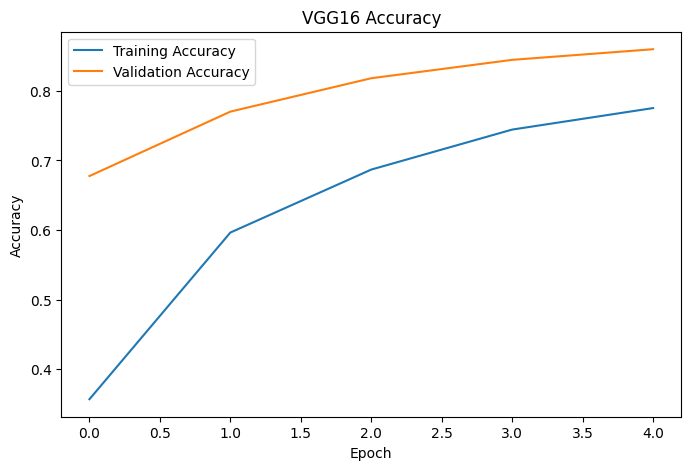

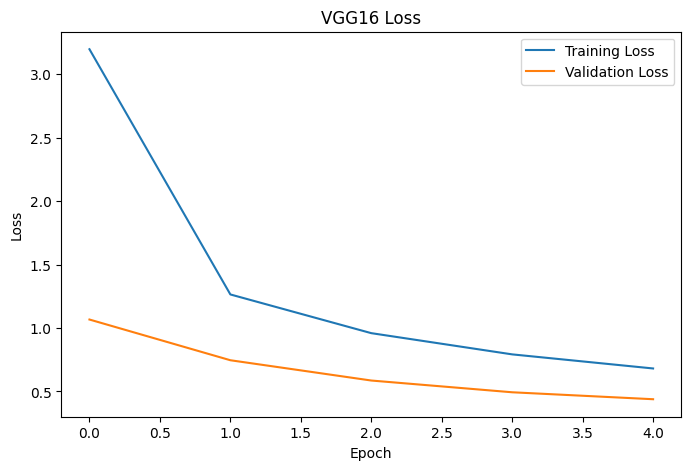

In [30]:
# Plot VGG16 accuracy
plt.figure(figsize=(8, 5))
plt.plot(vgg_history.history["accuracy"], label="Training Accuracy")
plt.plot(vgg_history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("VGG16 Accuracy")
plt.legend()
plt.show()

# Plot VGG16 loss
plt.figure(figsize=(8, 5))
plt.plot(vgg_history.history["loss"], label="Training Loss")
plt.plot(vgg_history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("VGG16 Loss")
plt.legend()
plt.show()

In [31]:
# Evaluate VGG16 on validation data
val_pretrained.reset()

vgg_loss, vgg_accuracy = vgg_model.evaluate(
    val_pretrained,
    verbose=1
)

print("VGG16 Validation Accuracy:", round(vgg_accuracy * 100, 2), "%")
print("VGG16 Validation Loss:", round(vgg_loss, 4))

129/129 ━━━━━━━━━━━━━━━━━━━━ 21s 158ms/step - accuracy: 0.8600 - loss: 0.4385
VGG16 Validation Accuracy: 86.0 %
VGG16 Validation Loss: 0.4385


In [32]:
# Load ResNet50 with ImageNet weights
resnet_base = ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

# Freeze the pre-trained layers
for layer in resnet_base.layers:
    layer.trainable = False

# Add a new classifier for PlantVillage
x = resnet_base.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation="relu")(x)
x = Dropout(0.5)(x)
output = Dense(NUM_CLASSES, activation="softmax")(x)

resnet_model = Model(resnet_base.input, output)

resnet_model.compile(
    optimizer=Adam(learning_rate=LEARNING_RATE),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

print("ResNet50 transfer learning model ready.")

ResNet50 transfer learning model ready.


In [33]:
# Train ResNet50
resnet_history = resnet_model.fit(
    train_pretrained,
    validation_data=val_pretrained,
    epochs=EPOCHS
)

Epoch 1/5
517/517 ━━━━━━━━━━━━━━━━━━━━ 79s 129ms/step - accuracy: 0.6306 - loss: 1.2176 - val_accuracy: 0.8658 - val_loss: 0.4939
Epoch 2/5
517/517 ━━━━━━━━━━━━━━━━━━━━ 56s 109ms/step - accuracy: 0.8323 - loss: 0.5551 - val_accuracy: 0.9110 - val_loss: 0.3244
Epoch 3/5
517/517 ━━━━━━━━━━━━━━━━━━━━ 58s 112ms/step - accuracy: 0.8762 - loss: 0.4006 - val_accuracy: 0.9267 - val_loss: 0.2631
Epoch 4/5
517/517 ━━━━━━━━━━━━━━━━━━━━ 82s 111ms/step - accuracy: 0.9008 - loss: 0.3200 - val_accuracy: 0.9313 - val_loss: 0.2288
Epoch 5/5
517/517 ━━━━━━━━━━━━━━━━━━━━ 58s 112ms/step - accuracy: 0.9179 - loss: 0.2728 - val_accuracy: 0.9430 - val_loss: 0.1912


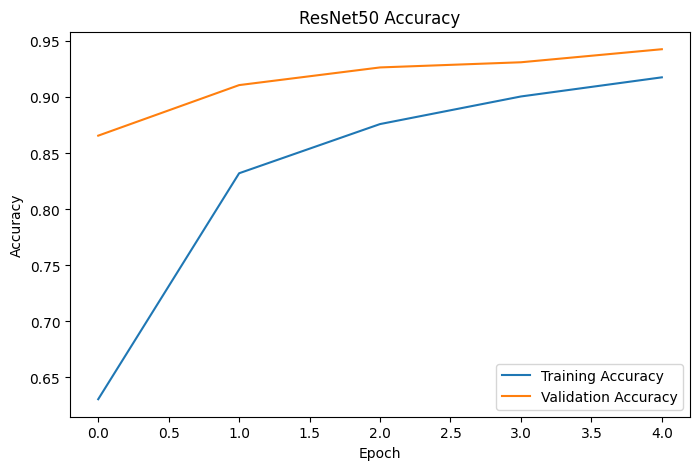

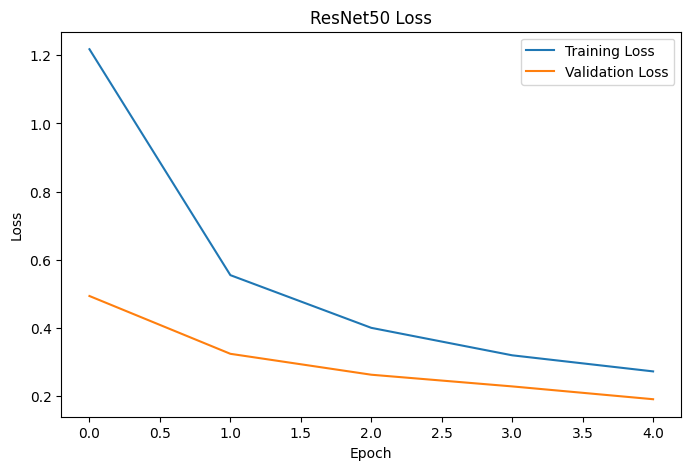

In [34]:
# Plot ResNet50 accuracy
plt.figure(figsize=(8, 5))
plt.plot(resnet_history.history["accuracy"], label="Training Accuracy")
plt.plot(resnet_history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("ResNet50 Accuracy")
plt.legend()
plt.show()

# Plot ResNet50 loss
plt.figure(figsize=(8, 5))
plt.plot(resnet_history.history["loss"], label="Training Loss")
plt.plot(resnet_history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("ResNet50 Loss")
plt.legend()
plt.show()

In [35]:
# Load EfficientNetB0 with ImageNet weights
efficientnet_base = EfficientNetB0(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

# Freeze the pre-trained layers
for layer in efficientnet_base.layers:
    layer.trainable = False

# Add a new classifier for PlantVillage
x = efficientnet_base.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation="relu")(x)
x = Dropout(0.5)(x)
output = Dense(NUM_CLASSES, activation="softmax")(x)

efficientnet_model = Model(efficientnet_base.input, output)

efficientnet_model.compile(
    optimizer=Adam(learning_rate=LEARNING_RATE),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

print("EfficientNetB0 transfer learning model ready.")

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
EfficientNetB0 transfer learning model ready.


In [ ]:
# Train EfficientNetB0
efficientnet_history = efficientnet_model.fit(
    train_pretrained,
    validation_data=val_pretrained,
    epochs=EPOCHS
)

Epoch 1/5
517/517 ━━━━━━━━━━━━━━━━━━━━ 112s 159ms/step - accuracy: 0.5894 - loss: 1.4316 - val_accuracy: 0.8256 - val_loss: 0.6981
Epoch 2/5
517/517 ━━━━━━━━━━━━━━━━━━━━ 43s 82ms/step - accuracy: 0.7969 - loss: 0.7018 - val_accuracy: 0.8814 - val_loss: 0.4462
Epoch 3/5
517/517 ━━━━━━━━━━━━━━━━━━━━ 46s 88ms/step - accuracy: 0.8455 - loss: 0.5147 - val_accuracy: 0.9100 - val_loss: 0.3434
Epoch 4/5
517/517 ━━━━━━━━━━━━━━━━━━━━ 43s 84ms/step - accuracy: 0.8720 - loss: 0.4235 - val_accuracy: 0.9212 - val_loss: 0.2890
Epoch 5/5
517/517 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - accuracy: 0.8884 - loss: 0.3758

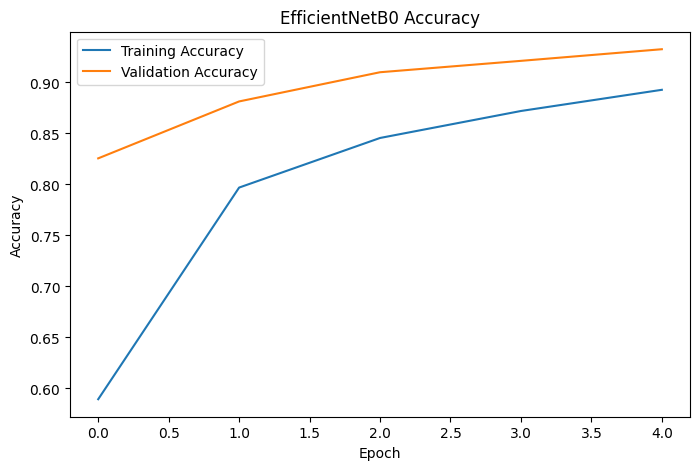

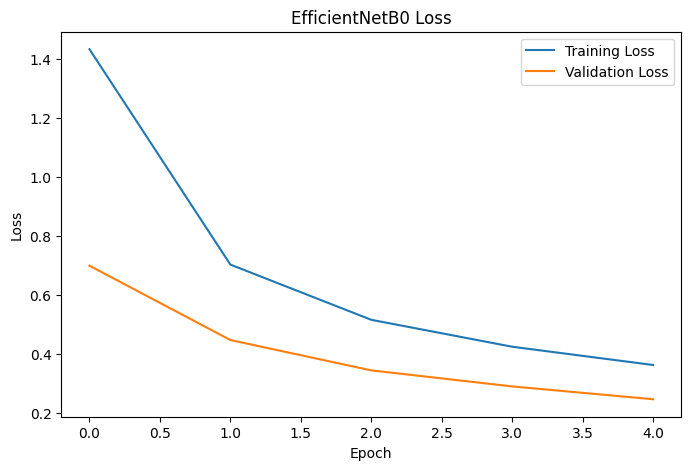

In [37]:
# Plot EfficientNetB0 accuracy
plt.figure(figsize=(8, 5))
plt.plot(efficientnet_history.history["accuracy"], label="Training Accuracy")
plt.plot(efficientnet_history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("EfficientNetB0 Accuracy")
plt.legend()
plt.show()

# Plot EfficientNetB0 loss
plt.figure(figsize=(8, 5))
plt.plot(efficientnet_history.history["loss"], label="Training Loss")
plt.plot(efficientnet_history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("EfficientNetB0 Loss")
plt.legend()
plt.show()

In [38]:
# Evaluate EfficientNetB0 on validation data
val_pretrained.reset()

efficientnet_loss, efficientnet_accuracy = efficientnet_model.evaluate(
    val_pretrained,
    verbose=1
)

print(
    "EfficientNetB0 Validation Accuracy:",
    round(efficientnet_accuracy * 100, 2),
    "%"
)
print(
    "EfficientNetB0 Validation Loss:",
    round(efficientnet_loss, 4)
)

129/129 ━━━━━━━━━━━━━━━━━━━━ 10s 75ms/step - accuracy: 0.9326 - loss: 0.2456
EfficientNetB0 Validation Accuracy: 93.26 %
EfficientNetB0 Validation Loss: 0.2456


In [39]:
# Generate predictions for all models
val_pretrained.reset()

vgg_pred = np.argmax(vgg_model.predict(val_pretrained), axis=1)

val_pretrained.reset()
resnet_pred = np.argmax(resnet_model.predict(val_pretrained), axis=1)

val_pretrained.reset()
efficientnet_pred = np.argmax(
    efficientnet_model.predict(val_pretrained), axis=1
)

# AlexNet uses the original validation generator
val_data.reset()
alexnet_pred = np.argmax(alexnet.predict(val_data), axis=1)

# Actual class labels
true_labels = val_pretrained.classes

print("Predictions generated successfully.")
print("Number of validation samples:", len(true_labels))

129/129 ━━━━━━━━━━━━━━━━━━━━ 23s 165ms/step
129/129 ━━━━━━━━━━━━━━━━━━━━ 19s 117ms/step
129/129 ━━━━━━━━━━━━━━━━━━━━ 24s 132ms/step
129/129 ━━━━━━━━━━━━━━━━━━━━ 12s 89ms/step
Predictions generated successfully.
Number of validation samples: 4122


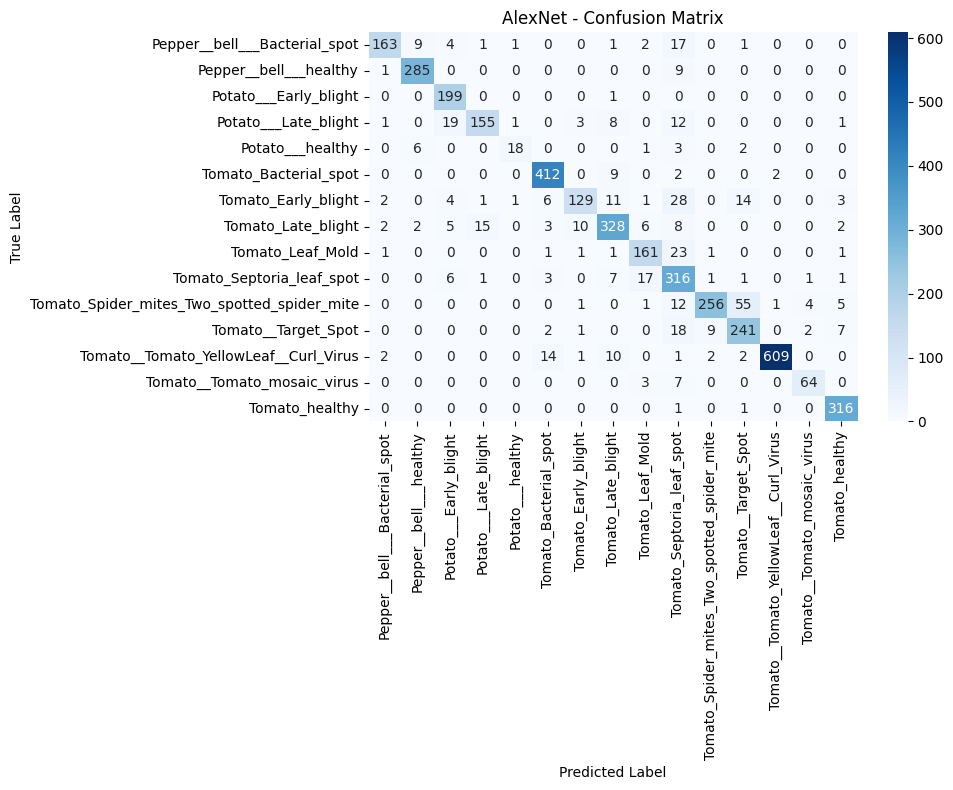

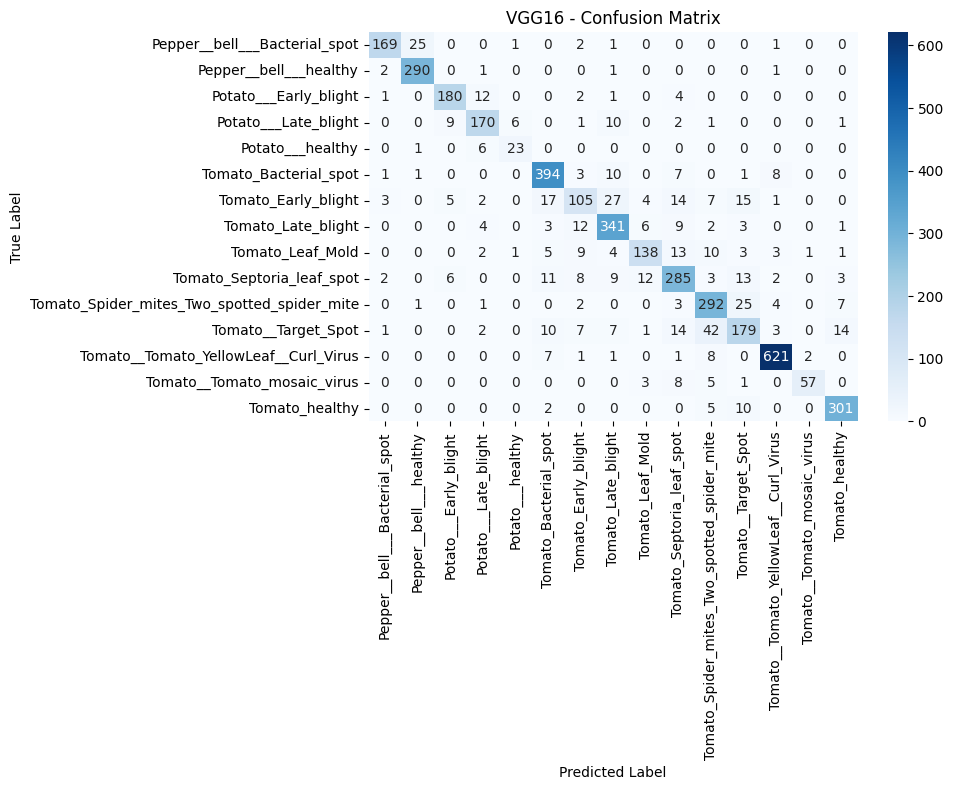

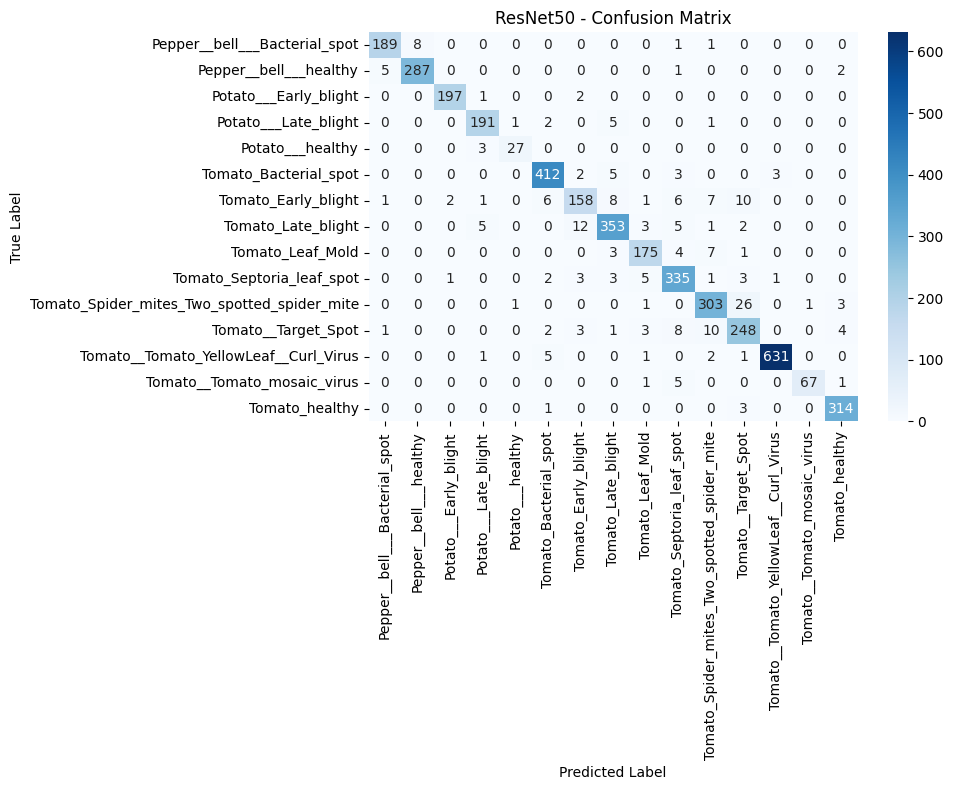

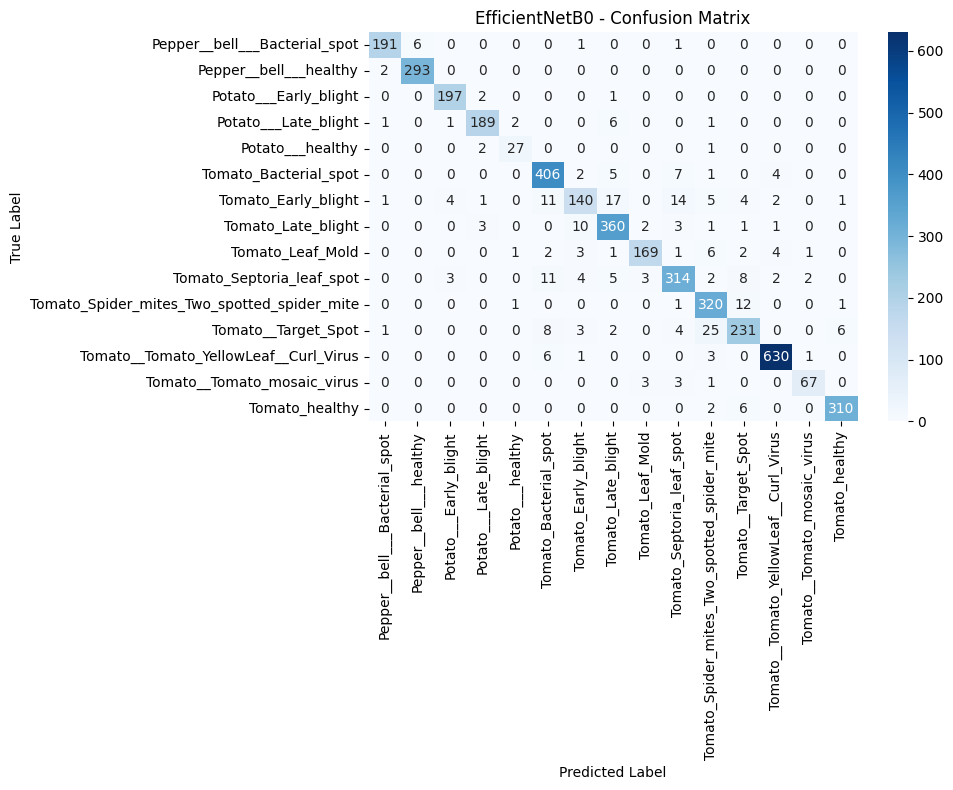

In [40]:
# Function to display a confusion matrix
def plot_confusion_matrix(true_labels, predictions, model_name):
    cm = confusion_matrix(true_labels, predictions)

    plt.figure(figsize=(10, 8))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=class_names,
        yticklabels=class_names
    )
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title(model_name + " - Confusion Matrix")
    plt.xticks(rotation=90)
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()


# Plot confusion matrices
plot_confusion_matrix(true_labels, alexnet_pred, "AlexNet")
plot_confusion_matrix(true_labels, vgg_pred, "VGG16")
plot_confusion_matrix(true_labels, resnet_pred, "ResNet50")
plot_confusion_matrix(true_labels, efficientnet_pred, "EfficientNetB0")

In [41]:
# Generate classification reports for all models

print("========== AlexNet ==========")
print(classification_report(
    true_labels,
    alexnet_pred,
    target_names=class_names
))

print("========== VGG16 ==========")
print(classification_report(
    true_labels,
    vgg_pred,
    target_names=class_names
))

print("========== ResNet50 ==========")
print(classification_report(
    true_labels,
    resnet_pred,
    target_names=class_names
))

print("========== EfficientNetB0 ==========")
print(classification_report(
    true_labels,
    efficientnet_pred,
    target_names=class_names
))

========== AlexNet ==========
                                             precision    recall  f1-score   support

              Pepper__bell___Bacterial_spot       0.95      0.82      0.88       199
                     Pepper__bell___healthy       0.94      0.97      0.95       295
                      Potato___Early_blight       0.84      0.99      0.91       200
                       Potato___Late_blight       0.90      0.78      0.83       200
                           Potato___healthy       0.86      0.60      0.71        30
                      Tomato_Bacterial_spot       0.93      0.97      0.95       425
                        Tomato_Early_blight       0.88      0.65      0.75       200
                         Tomato_Late_blight       0.87      0.86      0.87       381
                           Tomato_Leaf_Mold       0.84      0.85      0.84       190
                  Tomato_Septoria_leaf_spot       0.69      0.89      0.78       354
Tomato_Spider_mites_Two_spotted_sp

In [42]:
# Compare all four models
results = pd.DataFrame({
    "Model": ["AlexNet", "VGG16", "ResNet50", "EfficientNetB0"],
    "Validation Accuracy (%)": [
        alexnet_accuracy * 100,
        vgg_accuracy * 100,
        resnet_model.evaluate(val_pretrained, verbose=0)[1] * 100,
        efficientnet_accuracy * 100
    ]
})

results["Validation Accuracy (%)"] = results["Validation Accuracy (%)"].round(2)

print(results)

            Model  Validation Accuracy (%)
0         AlexNet                    88.60
1           VGG16                    86.00
2        ResNet50                    94.30
3  EfficientNetB0                    93.26


In [43]:
# Final model comparison
results = pd.DataFrame({
    "Model": ["AlexNet", "VGG16", "ResNet50", "EfficientNetB0"],
    "Accuracy (%)": [88.60, 86.00, 94.30, 93.26]
})

results = results.sort_values(
    by="Accuracy (%)",
    ascending=False
).reset_index(drop=True)

print(results)

            Model  Accuracy (%)
0        ResNet50         94.30
1  EfficientNetB0         93.26
2         AlexNet         88.60
3           VGG16         86.00


## Final Results

The four models were evaluated on the PlantVillage validation dataset.

| Model | Validation Accuracy |
|---|---:|
| ResNet50 | **94.30%** |
| EfficientNetB0 | **93.26%** |
| AlexNet | **88.60%** |
| VGG16 | **86.00%** |

### Conclusion

The experiment shows that transfer learning can provide strong performance for plant disease classification.

Among the tested models, **ResNet50 achieved the highest validation accuracy of 94.30%**, followed by EfficientNetB0 with 93.26%. AlexNet achieved 88.60%, while VGG16 achieved 86.00%.

Therefore, **ResNet50 performed best for the given PlantVillage dataset and experimental setup**.

The results demonstrate that pre-trained deep learning models can effectively learn plant disease features and classify multiple plant disease classes.